In [1]:
### Part 1: Data ingestion & schema design ###

In [2]:
# PART A:
#------ Field completeness rates, null distribution, and cardinality 

In [3]:
import pandas as pd

df = pd.read_excel("SampleDateExtract.xlsx")

print(df.shape)

(1000, 18)


In [4]:
# Completeness calculation
completeness = pd.DataFrame({
    'Column': df.columns,
    'Non_Null_Count': df.notna().sum().values,
    'Completeness_Rate (%)': (df.notna().sum()/len(df)*100).round(2)
})

completeness.reset_index(drop=True)

,Column,Non_Null_Count,Completeness_Rate (%)
0,ID-datalake,1000,100.0
1,nct_id,1000,100.0
2,brief_title,1000,100.0
3,official_title,994,99.4
4,phase,960,96.0
5,recruitment_status,1000,100.0
6,start_date,995,99.5
7,completion_date,948,94.8
8,primary_completion_date,949,94.9
9,enrollment,974,97.4


In [5]:
# Null Distribution
null_dist = pd.DataFrame({
    'Column': df.columns,
    'Null_Count': df.isna().sum().values,
    'Null_Percentage (%)': (df.isna().sum()/len(df)*100).round(2)
})

null_dist.sort_values(
    by='Null_Count',
    ascending=False
).reset_index(drop=True)

,Column,Null_Count,Null_Percentage (%)
0,completion_date,52,5.2
1,primary_completion_date,51,5.1
2,enrollment_type,44,4.4
3,phase,40,4.0
4,enrollment,26,2.6
5,official_title,6,0.6
6,start_date,5,0.5
7,ID-datalake,0,0.0
8,nct_id,0,0.0
9,recruitment_status,0,0.0


In [6]:
data_quality = pd.DataFrame({
    'Column': df.columns,
    'Non_Null_Count': df.notna().sum().values,
    'Null_Count': df.isna().sum().values,
    'Completeness (%)': (df.notna().sum()/len(df)*100).round(2),
    'Null (%)': (df.isna().sum()/len(df)*100).round(2)
})

data_quality.sort_values(
    by='Null_Count',
    ascending=False
).reset_index(drop=True)

,Column,Non_Null_Count,Null_Count,Completeness (%),Null (%)
0,completion_date,948,52,94.8,5.2
1,primary_completion_date,949,51,94.9,5.1
2,enrollment_type,956,44,95.6,4.4
3,phase,960,40,96.0,4.0
4,enrollment,974,26,97.4,2.6
5,official_title,994,6,99.4,0.6
6,start_date,995,5,99.5,0.5
7,ID-datalake,1000,0,100.0,0.0
8,nct_id,1000,0,100.0,0.0
9,recruitment_status,1000,0,100.0,0.0


In [7]:
### Conclusion:The dataset exhibited generally high data completeness, with most fields achieving 100% coverage. 
# Missing values were concentrated primarily in completion_date (5.2%), primary_completion_date (5.1%), enrollment_type (4.4%), phase (4.0%), and enrollment (2.6%). 
# Core analytical fields such as nct_id, recruitment_status, indications, interventions_drugs, technology classifications, and target annotations were fully populated. 
# The observed missingness is relatively low and unlikely to substantially impact cohort-level analyses, although missing phase and completion information may require special handling during success-rate calculations.

In [8]:
# Cardinality
cardinality = pd.DataFrame({
    'Column': df.columns,
    'Unique_Values': df.nunique(dropna=True).values
})

cardinality.sort_values(
    by='Unique_Values',
    ascending=False
).reset_index(drop=True)

,Column,Unique_Values
0,ID-datalake,1000
1,nct_id,1000
2,brief_title,1000
3,official_title,994
4,interventions_drugs,948
5,drugs_datalake,846
6,start_date,693
7,target_abbreviations,687
8,target_names,663
9,primary_completion_date,610


In [9]:
# Cardinality analysis identified a mixture of identifier fields, free-text descriptors, and controlled vocabulary fields.
# Unique identifiers (ID-datalake and nct_id) exhibited full uniqueness across all 1000 records, indicating no duplicate trial entries.
# Low-cardinality fields such as phase (7 values), recruitment_status (9 values), and enrollment_type (2 values) appear well-standardized and suitable for cohort stratification.
# High-cardinality fields including interventions_drugs (948 values), target_names (663 values), and indications (463 values) suggest substantial biological diversity and the presence of multi-valued entities that may benefit from normalization.


In [10]:
#------ Dirty values: inconsistent capitalisation, free-text synonyms, date format variation

In [11]:
# Checking phase values
print(df['phase'].unique())

['PHASE2' 'PHASE1' 'PHASE3' 'PHASE1/PHASE2' nan 'EARLY_PHASE1' 'PHASE4'
 'PHASE2/PHASE3']


In [12]:
# Conclusion: No meaningful capitalization inconsistency.

In [13]:
# Checking recruitment status
print(df['recruitment_status'].unique())

['NOT_YET_RECRUITING' 'RECRUITING' 'WITHDRAWN' 'ENROLLING_BY_INVITATION'
 'ACTIVE_NOT_RECRUITING' 'COMPLETED' 'UNKNOWN' 'TERMINATED' 'SUSPENDED']


In [14]:
# Conclusion: No free text synonym issues.

In [15]:
# Checking enrollment type
print(df['enrollment_type'].unique())

['ESTIMATED' 'ACTUAL' nan]


In [16]:
# Conclusion: Only 2 values. Controlled vocabulary already enforced.

In [17]:
# Checking format of date columns
df[['start_date',
    'primary_completion_date',
    'completion_date']].head(10)

,start_date,primary_completion_date,completion_date
0,2026-01-13,2029-03-26,2029-03-26
1,2025-10-01,2026-10-01,2026-10-01
2,2025-06-30,2025-12-30,2026-06-30
3,2025-05-31,2027-08-31,2028-08-31
4,2025-05-31,2027-05-31,2028-12-31
5,2025-05-01,2026-04-30,2027-12-31
6,2025-05-01,2026-12-31,2026-12-31
7,2025-04-30,2025-07-01,2025-07-01
8,2025-04-10,2026-01-31,2027-01-31
9,2025-04-02,2027-04-01,2027-04-01


In [18]:
# Conclusion: No meaningful date-format inconsistency.

In [19]:
# Checking data types
df[['start_date',
    'primary_completion_date',
    'completion_date']].dtypes

start_date                 datetime64[ns]
primary_completion_date    datetime64[ns]
completion_date            datetime64[ns]
dtype: object

In [20]:
# Inspect multivalued fields
df[['indications',
    'interventions_drugs',
    'main_technologies']].head(5)

,indications,interventions_drugs,main_technologies
0,"['Anorectal Cancer', 'Epithelial Neoplasm']","['Pembrolizumab', 'Lenvatinib']","[['Antibody'], ['Small Molecule']]"
1,['Thoracic Neoplasm'],['Tislelizumab'],[['Antibody']]
2,['Ovarian Cancer'],['Innocell'],[['Cancer Vaccine']]
3,['Small Intestinal Adenocarcinoma'],"['Irinotecan Sucrosofate', 'Dexamethasone', '5...","[['Small Molecule'], ['Small Molecule'], ['Sma..."
4,['Pancreatic Cancer'],"['Retifanlimab', 'Oxaliplatin', 'Folinic acid'...","[['Antibody'], ['Small Molecule'], [], ['Small..."


In [21]:
# these results are looking more like strings than python list. So, I willl check their data-type

In [22]:
type(df['indications'].iloc[0])

str

In [23]:
type(df['interventions_drugs'].iloc[0])

str

In [24]:
type(df['main_technologies'].iloc[0])

str

In [25]:
type(df['specific_technologies'].iloc[0])

str

In [26]:
type(df['target_names'].iloc[0])

str

In [27]:
type(df['target_abbreviations'].iloc[0])

str

In [28]:
# Structural Anomaly
(df['completion_date'] < df['start_date']).sum()

np.int64(0)

In [29]:
# no impossible timeline (start date after completion date) present

In [30]:
(df['primary_completion_date'] < df['start_date']).sum()

np.int64(0)

In [31]:
(df['enrollment'] < 0).sum()

np.int64(0)

In [32]:
df['nct_id'].duplicated().sum()

np.int64(0)

In [33]:
# no duplicate id present

In [34]:
df['nct_id'].isna().sum()

np.int64(0)

In [35]:
# no missing trial id

In [36]:
(df['enrollment'] == 0).sum()

np.int64(39)

In [37]:
# Checking for Misaligned columns
df['phase'].value_counts(dropna=False)

phase
PHASE2           402
PHASE1           253
PHASE1/PHASE2    126
PHASE3           124
NaN               40
PHASE4            25
PHASE2/PHASE3     17
EARLY_PHASE1      13
Name: count, dtype: int64

In [38]:
# Recruitment status validation
df['recruitment_status'].value_counts(dropna=False)

recruitment_status
COMPLETED                  453
RECRUITING                 140
TERMINATED                 123
UNKNOWN                    121
ACTIVE_NOT_RECRUITING       76
NOT_YET_RECRUITING          41
WITHDRAWN                   40
SUSPENDED                    4
ENROLLING_BY_INVITATION      2
Name: count, dtype: int64

In [39]:
# Data type consistency
df.dtypes

ID-datalake                         int64
nct_id                             object
brief_title                        object
official_title                     object
phase                              object
recruitment_status                 object
start_date                 datetime64[ns]
completion_date            datetime64[ns]
primary_completion_date    datetime64[ns]
enrollment                        float64
enrollment_type                    object
indications                        object
interventions_drugs                object
drugs_datalake                     object
main_technologies                  object
specific_technologies              object
target_names                       object
target_abbreviations               object
dtype: object

In [40]:
# Checking for merged cells
df['nct_id'].isna().sum()

np.int64(0)

In [41]:
df.isna().sum(axis=1).value_counts().sort_index()

0    866
1     80
2     29
3     15
4      9
5      1
Name: count, dtype: int64

In [42]:
df[df.isna().sum(axis=1) > 5]

,ID-datalake,nct_id,brief_title,official_title,phase,recruitment_status,start_date,completion_date,primary_completion_date,enrollment,enrollment_type,indications,interventions_drugs,drugs_datalake,main_technologies,specific_technologies,target_names,target_abbreviations


In [43]:
# No records exhibited extensive missingness (>5 fields).

In [44]:
# Conclusion:
# Structural Anomaly Assessment:
# No duplicate or missing trial identifiers were detected, indicating that each record uniquely represents a clinical trial.
# Temporal validation identified no cases where completion dates or primary completion dates preceded trial start dates, suggesting internally consistent timeline information.
# Enrollment values were non-negative across all records, although 39 trials reported zero enrollment, likely corresponding to withdrawn, inactive, or pre-enrollment studies.
# Controlled-vocabulary fields such as phase and recruitment_status contained only expected values, with no evidence of column shifting or data-type contamination.
# Data type inspection confirmed appropriate assignment of numeric, datetime, and categorical fields.
# Row-level missingness analysis showed that 866 of 1000 records contained no missing values.
# No records exhibited extensive missingness (>5 fields), providing little evidence of merged-cell corruption or large-scale row misalignment.
# The primary structural limitation identified was the storage of multi-valued entities (e.g., indications, interventions, technologies, and targets) as serialized string representations rather than normalized relational structures.

In [45]:
# PART B:
#------ B. Design a clean analytical schema: Propose and implement a normalised schema suited for cohort-level analysis. Consider how you would handle:
# Multi-valued fields (e.g. a trial testing a combination therapy listed in one cell)

In [46]:
type(df['drugs_datalake'].iloc[0])
df[['interventions_drugs','drugs_datalake']].head(5)

,interventions_drugs,drugs_datalake
0,"['Pembrolizumab', 'Lenvatinib']","['B936', 'B261']"
1,['Tislelizumab'],['B1344']
2,['Innocell'],['B11796']
3,"['Irinotecan Sucrosofate', 'Dexamethasone', '5...","['B1128', 'B1229', 'B493', 'B226']"
4,"['Retifanlimab', 'Oxaliplatin', 'Folinic acid'...","['B1394', 'B1229', 'B226', 'B1679', 'B493', 'B..."


In [47]:
# Several biologically meaningful attributes, including indications, interventions, drug identifiers, technologies, and targets, were stored as multi-valued string representations within individual cells.
# To support cohort-level analysis, these entities were normalized into separate dimension tables connected through many-to-many bridge tables.
# This design eliminates redundancy and improves data organization.
# It enables efficient aggregation and querying across diseases, drugs, technologies, and targets.
# The normalized structure also facilitates downstream computation of stratified success metrics and other analytical workflows.

In [48]:
import ast

In [51]:
multi_cols = [
    'indications',
    'interventions_drugs',
    'drugs_datalake',
    'main_technologies',
    'specific_technologies',
    'target_names',
    'target_abbreviations'
]

for col in multi_cols:
    df[col] = df[col].apply(
        lambda x: ast.literal_eval(x)
        if isinstance(x, str)
        else x
    )

In [52]:
print(type(df['interventions_drugs'].iloc[0]))
print(df['interventions_drugs'].iloc[0])

print(type(df['drugs_datalake'].iloc[0]))
print(df['drugs_datalake'].iloc[0])

print(type(df['main_technologies'].iloc[0]))
print(df['main_technologies'].iloc[0])

<class 'list'>
['Pembrolizumab', 'Lenvatinib']
<class 'list'>
['B936', 'B261']
<class 'list'>
[['Antibody'], ['Small Molecule']]


In [ ]:
# actual normalized tables

In [53]:
# trials table
trials = df[
[
'nct_id',
'ID-datalake',
'brief_title',
'official_title',
'phase',
'recruitment_status',
'start_date',
'primary_completion_date',
'completion_date',
'enrollment',
'enrollment_type'
]
].copy()

trials.head()

,nct_id,ID-datalake,brief_title,official_title,phase,recruitment_status,start_date,primary_completion_date,completion_date,enrollment,enrollment_type
0,NCT06669572,61690,Lenvatinib and Pembrolizumab to Treat Patients...,"A Phase II, Multi-center, Single Arm Trial of ...",PHASE2,NOT_YET_RECRUITING,2026-01-13,2029-03-26,2029-03-26,35.0,ESTIMATED
1,NCT06883552,63117,"An Open-label, Single-arm Clinical Study of St...","An Open-label, Single-arm Clinical Study of St...",PHASE2,NOT_YET_RECRUITING,2025-10-01,2026-10-01,2026-10-01,21.0,ESTIMATED
2,NCT06366490,56177,Safety and Immunogenicity of Innocell Autologo...,Phase 1 Study to Assess the Safety and Immunog...,PHASE1,NOT_YET_RECRUITING,2025-06-30,2025-12-30,2026-06-30,8.0,ESTIMATED
3,NCT06835387,62820,Study of NALIRIFOX in Advanced Unresectable Sm...,Phase II Study of NALIRIFOX (Nanoliposomal Iri...,PHASE2,RECRUITING,2025-05-31,2027-08-31,2028-08-31,36.0,ESTIMATED
4,NCT06896188,63206,"9-ING-41 Combined with Retifanlimab, Plus Modi...","A Phase Ib Study of 9-ING-41 (elraglusib), a G...",PHASE1,NOT_YET_RECRUITING,2025-05-31,2027-05-31,2028-12-31,12.0,ESTIMATED


In [54]:
# trial drug bridge
trial_drugs = (
    df[['nct_id','drugs_datalake']]
    .explode('drugs_datalake')
    .rename(
        columns={
            'drugs_datalake':'drug_datalake_id'
        }
    )
)

trial_drugs.head()

,nct_id,drug_datalake_id
0,NCT06669572,B936
0,NCT06669572,B261
1,NCT06883552,B1344
2,NCT06366490,B11796
3,NCT06835387,B1128


In [55]:
# drug dimension
drug_pairs = []

for _, row in df.iterrows():

    drugs = row['interventions_drugs']
    ids = row['drugs_datalake']

    for d,i in zip(drugs,ids):

        drug_pairs.append(
            [i,d]
        )

drugs = (
    pd.DataFrame(
        drug_pairs,
        columns=[
            'drug_datalake_id',
            'drug_name'
        ]
    )
    .drop_duplicates()
)

drugs.head()

,drug_datalake_id,drug_name
0,B936,Pembrolizumab
1,B261,Lenvatinib
2,B1344,Tislelizumab
3,B11796,Innocell
4,B1128,Irinotecan Sucrosofate


In [56]:
# triasl-indication bridge
trial_indications = (
    df[['nct_id','indications']]
    .explode('indications')
    .rename(
        columns={
            'indications':'indication_name'
        }
    )
)

trial_indications.head()

,nct_id,indication_name
0,NCT06669572,Anorectal Cancer
0,NCT06669572,Epithelial Neoplasm
1,NCT06883552,Thoracic Neoplasm
2,NCT06366490,Ovarian Cancer
3,NCT06835387,Small Intestinal Adenocarcinoma


In [57]:
# indication dimension
indications = pd.DataFrame(
    {
        'indication_name':
        sorted(
            trial_indications['indication_name']
            .dropna()
            .unique()
        )
    }
)

indications['indication_id'] = (
    indications.index + 1
)

indications.head()

,indication_name,indication_id
0,AML with maturation,1
1,AML with minimal differentiation,2
2,AML without maturation,3
3,Abdominal Neoplasms,4
4,Acral Lentiginous Melanoma,5


In [58]:
print(trials.shape)
print(drugs.shape)
print(trial_drugs.shape)
print(indications.shape)
print(trial_indications.shape)

(1000, 11)
(907, 2)
(2217, 2)
(437, 2)
(2231, 2)


In [ ]:
# Conclusion:
# Multi-valued attributes were decomposed into separate dimension and bridge tables.
# Drug identifiers and intervention names were normalized into the Drugs and Trial_Drugs tables.
# Disease indications were normalized into the Indications and Trial_Indications tables.
# This transformation converted embedded list structures into analyzable many-to-many relationships.
# The resulting schema enables cohort-level aggregation and analysis by drug and disease category.

In [59]:
df[['main_technologies',
    'specific_technologies',
    'target_names',
    'target_abbreviations']].head(5)

,main_technologies,specific_technologies,target_names,target_abbreviations
0,"[[Antibody], [Small Molecule]]","[[Monoclonal Antibody], [Small Molecule]]","[[Programmed cell death protein 1], [Fibroblas...","[[PD-1], [FGFR1, FGFR2, FGFR3, FGFR4, PDGFRÎ±,..."
1,[[Antibody]],[[Monoclonal Antibody]],[[Programmed cell death protein 1]],[[PD-1]]
2,[[Cancer Vaccine]],[[Whole Tumor Cell Vaccine]],[[]],[[]]
3,"[[Small Molecule], [Small Molecule], [Small Mo...","[[Small Molecule], [Small Molecule], [Small Mo...","[[Glucocorticoid receptor], [DNA], [Thymidylat...","[[GR], [DNA], [TYMS], []]"
4,"[[Antibody], [Small Molecule], [], [Small Mole...","[[Monoclonal Antibody], [Small Molecule], [], ...","[[Programmed cell death protein 1], [DNA], [],...","[[PD-1], [DNA], [], [TOP1], [TYMS], [GSK-3Î²]]"


In [60]:
print(df['main_technologies'].iloc[0])
print(df['specific_technologies'].iloc[0])
print(df['target_names'].iloc[0])
print(df['target_abbreviations'].iloc[0])

[['Antibody'], ['Small Molecule']]
[['Monoclonal Antibody'], ['Small Molecule']]
[['Programmed cell death protein 1'], ['Fibroblast growth factor receptor 1', 'Fibroblast growth factor receptor 2', 'Fibroblast growth factor receptor 3', 'Fibroblast growth factor receptor 4', 'Platelet-derived growth factor receptor alpha', 'Stem cell growth factor receptor', 'Tyrosine-protein kinase receptor RET', 'Vascular endothelial growth factor receptor 1', 'Vascular endothelial growth factor receptor 2', 'Vascular endothelial growth factor receptor 3']]
[['PD-1'], ['FGFR1', 'FGFR2', 'FGFR3', 'FGFR4', 'PDGFRÎ±', 'c-Kit', 'RET', 'VEGFR1', 'VEGFR2', 'VEGFR3']]


In [61]:
# technology normalization
technology_rows = []

for _, row in df.iterrows():

    trial = row['nct_id']

    for tech in row['main_technologies']:

        if len(tech) > 0:

            technology_rows.append(
                [trial, tech[0]]
            )

trial_technologies = pd.DataFrame(
    technology_rows,
    columns=[
        'nct_id',
        'technology_name'
    ]
)

trial_technologies.head()

,nct_id,technology_name
0,NCT06669572,Antibody
1,NCT06669572,Small Molecule
2,NCT06883552,Antibody
3,NCT06366490,Cancer Vaccine
4,NCT06835387,Small Molecule


In [62]:
technologies = pd.DataFrame(
    {
        'technology_name':
        sorted(
            trial_technologies[
                'technology_name'
            ].unique()
        )
    }
)

technologies['technology_id'] = (
    technologies.index + 1
)

technologies.head()

,technology_name,technology_id
0,Antibody,1
1,Antibody Drug Conjugate (ADC),2
2,Antibody Radiopharmaceutical,3
3,Antisense Oligonucleotide (ASO),4
4,Cancer Vaccine,5


In [63]:
# target normalisation
target_rows = []

for _, row in df.iterrows():

    trial = row['nct_id']

    names = row['target_names']
    abbrs = row['target_abbreviations']

    for n,a in zip(names,abbrs):

        if len(n) > 0:

            target_rows.append(
                [
                    trial,
                    n[0],
                    a[0] if len(a) > 0 else None
                ]
            )

trial_targets = pd.DataFrame(
    target_rows,
    columns=[
        'nct_id',
        'target_name',
        'target_abbreviation'
    ]
)

trial_targets.head()

,nct_id,target_name,target_abbreviation
0,NCT06669572,Programmed cell death protein 1,PD-1
1,NCT06669572,Fibroblast growth factor receptor 1,FGFR1
2,NCT06883552,Programmed cell death protein 1,PD-1
3,NCT06835387,Glucocorticoid receptor,GR
4,NCT06835387,DNA,DNA


In [64]:
targets = (
    trial_targets[
        [
            'target_name',
            'target_abbreviation'
        ]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

targets['target_id'] = (
    targets.index + 1
)

targets.head()

,target_name,target_abbreviation,target_id
0,Programmed cell death protein 1,PD-1,1
1,Fibroblast growth factor receptor 1,FGFR1,2
2,Glucocorticoid receptor,GR,3
3,DNA,DNA,4
4,Thymidylate synthase,TYMS,5


In [65]:
# Schema Summary
schema_summary = pd.DataFrame({
    'Table' : [
        'Trials',
        'Drugs',
        'Trial_Drugs',
        'Indications',
        'Trial_Indications',
        'Technologies',
        'Trial_Technologies',
        'Targets',
        'Trial_Targets'
    ],
    'Rows' : [
        len(trials),
        len(drugs),
        len(trial_drugs),
        len(indications),
        len(trial_indications),
        len(technologies),
        len(trial_technologies),
        len(targets),
        len(trial_targets)
    ]
})

schema_summary

,Table,Rows
0,Trials,1000
1,Drugs,907
2,Trial_Drugs,2217
3,Indications,437
4,Trial_Indications,2231
5,Technologies,31
6,Trial_Technologies,1966
7,Targets,255
8,Trial_Targets,1830


In [ ]:
# The normalized schema transformed embedded multi-valued attributes into separate dimension and bridge tables.
# The resulting structure contained 1000 trial records, 907 unique drugs, 437 indications, 31 technology classes, and 255 molecular targets.
# Many-to-many relationships were represented through bridge tables, including Trial_Drugs, Trial_Indications, Trial_Technologies, and Trial_Targets.
# This design supports efficient cohort-level aggregation and stratified success-rate analyses.

In [ ]:
#-------- Controlled vocabularies – standardising free-text status, phase, and indication values

In [66]:
# mapping
phase_map = {
    'EARLY_PHASE1' : 'PHASE1',
    'PHASE1' : 'PHASE1',
    'PHASE1/PHASE2' : 'PHASE1_2',
    'PHASE2' : 'PHASE2',
    'PHASE2/PHASE3' : 'PHASE2_3',
    'PHASE3' : 'PHASE3',
    'PHASE4' : 'PHASE4'
}

status_map = {
    'COMPLETED' : 'COMPLETED',
    'RECRUITING' : 'RECRUITING',
    'ENROLLING_BY_INVITATION' : 'RECRUITING',
    'ACTIVE_NOT_RECRUITING' : 'ACTIVE',
    'NOT_YET_RECRUITING' : 'PRE_RECRUITMENT',
    'WITHDRAWN' : 'WITHDRAWN',
    'TERMINATED' : 'TERMINATED',
    'SUSPENDED' : 'SUSPENDED',
    'UNKNOWN' : 'UNKNOWN'
}

In [67]:
trials['phase_standardized'] = (
    trials['phase']
    .map(phase_map)
)

trials['status_standardized'] = (
    trials['recruitment_status']
    .map(status_map)
)

In [68]:
trials[
[
'phase',
'phase_standardized',
'recruitment_status',
'status_standardized'
]
].head(10)

,phase,phase_standardized,recruitment_status,status_standardized
0,PHASE2,PHASE2,NOT_YET_RECRUITING,PRE_RECRUITMENT
1,PHASE2,PHASE2,NOT_YET_RECRUITING,PRE_RECRUITMENT
2,PHASE1,PHASE1,NOT_YET_RECRUITING,PRE_RECRUITMENT
3,PHASE2,PHASE2,RECRUITING,RECRUITING
4,PHASE1,PHASE1,NOT_YET_RECRUITING,PRE_RECRUITMENT
5,PHASE2,PHASE2,NOT_YET_RECRUITING,PRE_RECRUITMENT
6,PHASE2,PHASE2,NOT_YET_RECRUITING,PRE_RECRUITMENT
7,PHASE2,PHASE2,WITHDRAWN,WITHDRAWN
8,PHASE1,PHASE1,RECRUITING,RECRUITING
9,PHASE3,PHASE3,RECRUITING,RECRUITING


In [ ]:
# Conclusion:
# Controlled vocabularies were introduced for trial phase and recruitment status to ensure consistent analytical grouping.
# Early-phase and hybrid-phase labels were mapped to canonical phase categories.
# Recruitment statuses were consolidated into broader operational states such as RECRUITING, ACTIVE, COMPLETED, and TERMINATED.
# Disease indications were retained as originally recorded in the source data.
# Ideally, disease indications would be mapped to a controlled oncology ontology such as NCIt or Disease Ontology.
# Ontology-based harmonization would standardize synonymous disease labels and improve cross-study aggregation and comparative analyses.

In [69]:
# Showing all unique indications

unique_indications = sorted(
    indications['indication_name']
    .dropna()
    .unique()
)

for ind in unique_indications:
    print(ind)

AML with maturation
AML with minimal differentiation
AML without maturation
Abdominal Neoplasms
Acral Lentiginous Melanoma
Acral Melanoma
Actinic Keratosis
Acute Chest Syndrome
Acute Erythroid Leukemia
Acute Graft Versus Host Disease
Acute Leukemia
Acute Lymphoblastic Leukemia
Acute Megakaryoblastic Leukemia
Acute Monocytic Leukemia
Acute Myeloid Leukemia
Acute Myelomonocytic Leukemia
Adenocarcinoma of the Ovaries
Adjuvant Therapy
Adoptive Cellular Immunotherapy
Adrenal Gland Pheochromocytoma
Adult Supratentorial Primitive Neuroectodermal Tumor (PNET)
Adult T-Cell Leukemia/Lymphoma
Advanced Cancers Harbouring Mutations in HRG
Advanced Gastrointestinal Carcinoma
Advanced Stage Cancer
Allogeneic Hematopoietic Stem Cell Transplantation
Allogeneic Stem Cell Transplantation
Alveolar Soft Part Sarcoma
Anal Cancer
Analgesia
Anaplastic Astrocytoma
Anaplastic Large Cell Lymphoma
Anaplastic Oligodendroglioma
Anastomotic Leak
Androgen Receptor Gene Overexpression
Androgen-insensitive Prostate Can

In [70]:
# Save all unique indications to a text file

with open("unique_indications.txt", "w", encoding="utf-8") as f:
    for ind in sorted(indications['indication_name'].dropna().unique()):
        f.write(ind + "\n")

print("Saved successfully!")

Saved successfully!


In [71]:
print(len(unique_indications))

437


In [72]:
# Creating major disease area categories
INDICATION_GROUPS = [
    'HEMATOLOGIC_MALIGNANCY',
    'THORACIC_CANCER',
    'BREAST_CANCER',
    'GASTROINTESTINAL_CANCER',
    'HEPATOBILIARY_CANCER',
    'GYNECOLOGIC_CANCER',
    'GENITOURINARY_CANCER',
    'HEAD_AND_NECK_CANCER',
    'CNS_TUMOR',
    'SKIN_AND_MELANOMA',
    'SARCOMA',
    'ENDOCRINE_NEOPLASM',
    'PEDIATRIC_EMBRYONAL_TUMOR',
    'HEMATOLOGIC_NON_MALIGNANT',
    'NON_ONCOLOGY_CONDITION',
    'BIOMARKER_DEFINED_COHORT',
    'PAN_TUMOR',
    'OTHER_SOLID_TUMOR'
]

In [73]:
# Comprehensive mapping function
def standardize_indication(ind):

    ind = str(ind).lower()

    # -----------------------------
    # Hematologic malignancies
    # -----------------------------
    if any(x in ind for x in [
        'leukemia','lymphoma','myeloma',
        'myelodysplastic','myeloproliferative',
        'plasmacytoma','waldenstrom',
        'hodgkin','non-hodgkin',
        'lymphoblastic'
    ]):
        return 'HEMATOLOGIC_MALIGNANCY'

    # -----------------------------
    # Thoracic cancers
    # -----------------------------
    elif any(x in ind for x in [
        'lung','thoracic','nsclc',
        'small cell lung','mesothelioma'
    ]):
        return 'THORACIC_CANCER'

    # -----------------------------
    # Breast cancers
    # -----------------------------
    elif 'breast' in ind:
        return 'BREAST_CANCER'

    # -----------------------------
    # Hepatobiliary cancers
    # -----------------------------
    elif any(x in ind for x in [
        'hepatocellular',
        'cholangiocarcinoma',
        'bile duct',
        'gallbladder',
        'liver cancer'
    ]):
        return 'HEPATOBILIARY_CANCER'

    # -----------------------------
    # Gastrointestinal cancers
    # -----------------------------
    elif any(x in ind for x in [
        'colon',
        'colorectal',
        'rectal',
        'gastric',
        'esophageal',
        'gastro-esophageal',
        'gastrointestinal',
        'pancreatic',
        'anal cancer',
        'anorectal',
        'small intestinal'
    ]):
        return 'GASTROINTESTINAL_CANCER'

    # -----------------------------
    # Gynecologic cancers
    # -----------------------------
    elif any(x in ind for x in [
        'ovarian',
        'endometrial',
        'cervical',
        'fallopian',
        'uterine',
        'vulvar',
        'gestational trophoblastic'
    ]):
        return 'GYNECOLOGIC_CANCER'

    # -----------------------------
    # Genitourinary cancers
    # -----------------------------
    elif any(x in ind for x in [
        'prostate',
        'renal',
        'kidney',
        'bladder',
        'urothelial',
        'urethral',
        'urinary tract',
        'testicular'
    ]):
        return 'GENITOURINARY_CANCER'

    # -----------------------------
    # CNS tumors
    # -----------------------------
    elif any(x in ind for x in [
        'glioma',
        'glioblastoma',
        'astrocytoma',
        'ependymoma',
        'medulloblastoma',
        'neuroectodermal',
        'pineoblastoma',
        'brain metastasis',
        'cns'
    ]):
        return 'CNS_TUMOR'

    # -----------------------------
    # Head and neck
    # -----------------------------
    elif any(x in ind for x in [
        'head and neck',
        'laryngeal',
        'oropharyngeal',
        'hypopharyngeal',
        'nasopharyngeal',
        'salivary gland',
        'oral cavity'
    ]):
        return 'HEAD_AND_NECK_CANCER'

    # -----------------------------
    # Skin / melanoma
    # -----------------------------
    elif any(x in ind for x in [
        'melanoma',
        'merkel',
        'basal cell',
        'skin squamous',
        'skin neoplasm'
    ]):
        return 'SKIN_AND_MELANOMA'

    # -----------------------------
    # Sarcomas
    # -----------------------------
    elif any(x in ind for x in [
        'sarcoma',
        'osteosarcoma',
        'chondrosarcoma',
        'liposarcoma',
        'leiomyosarcoma',
        'ewing'
    ]):
        return 'SARCOMA'

    # -----------------------------
    # Endocrine tumors
    # -----------------------------
    elif any(x in ind for x in [
        'thyroid',
        'parathyroid',
        'neuroendocrine',
        'pheochromocytoma',
        'paraganglioma'
    ]):
        return 'ENDOCRINE_NEOPLASM'

    # -----------------------------
    # Biomarker cohorts
    # -----------------------------
    elif any(x in ind for x in [
        'fgfr',
        'kras',
        'braf',
        'pten',
        'her2',
        'her-2',
        'ros1',
        'cdk',
        'pi3k'
    ]):
        return 'BIOMARKER_DEFINED_COHORT'

    # -----------------------------
    # Non-malignant hematology
    # -----------------------------
    elif any(x in ind for x in [
        'anemia',
        'thalassemia',
        'sickle cell',
        'aplastic anemia',
        'thrombocytopenia',
        'hemoglobinopathies'
    ]):
        return 'HEMATOLOGIC_NON_MALIGNANT'

    # -----------------------------
    # Pan-cancer cohorts
    # -----------------------------
    elif any(x in ind for x in [
        'solid tumors',
        'advanced cancers',
        'pan-tumor',
        'cancer',
        'malignant neoplasm',
        'tumors'
    ]):
        return 'PAN_TUMOR'

    # -----------------------------
    # Non-oncology conditions
    # -----------------------------
    elif any(x in ind for x in [
        'covid',
        'kidney disease',
        'hepatitis',
        'atherosclerosis',
        'inflammation',
        'parkinson',
        'infection'
    ]):
        return 'NON_ONCOLOGY_CONDITION'

    else:
        return 'OTHER_SOLID_TUMOR'

In [74]:
# implementation
trial_indications['indication_group'] = (
    trial_indications['indication_name']
    .apply(standardize_indication)
)

In [75]:
trial_indications['indication_group'].value_counts()

indication_group
HEMATOLOGIC_MALIGNANCY       487
OTHER_SOLID_TUMOR            444
GASTROINTESTINAL_CANCER      217
GENITOURINARY_CANCER         158
BREAST_CANCER                145
PAN_TUMOR                    135
THORACIC_CANCER              133
HEAD_AND_NECK_CANCER         120
CNS_TUMOR                     83
GYNECOLOGIC_CANCER            74
HEPATOBILIARY_CANCER          60
SKIN_AND_MELANOMA             47
SARCOMA                       40
HEMATOLOGIC_NON_MALIGNANT     39
ENDOCRINE_NEOPLASM            23
BIOMARKER_DEFINED_COHORT      15
NON_ONCOLOGY_CONDITION        11
Name: count, dtype: int64

In [76]:
# Quality check
trial_indications[
    trial_indications['indication_group'] == 'OTHER_SOLID_TUMOR'
]['indication_name'].drop_duplicates().sort_values()

514                 AML with maturation
542    AML with minimal differentiation
542              AML without maturation
802                 Abdominal Neoplasms
488                   Actinic Keratosis
                     ...               
152             Urinary System Neoplasm
441                 Vascular Thrombosis
808               Vaso-occlusive Crisis
375              Venous Thromboembolism
171                               aGVHD
Name: indication_name, Length: 160, dtype: object

In [ ]:
# The result tells us the first-pass mapping is not good enough yet.
# The category OTHER_SOLID_TUMOR still contains 444 records, which is about 20% of all indication records.
# In addition, 160 unique disease indications remain grouped under this category.
# This suggests that many disease names have not yet been mapped to more specific disease groups.
# For a well-curated controlled vocabulary, less than 10–15% of indications should fall into a catch-all category.
# Further disease harmonization and ontology mapping are needed to reduce the size of the OTHER_SOLID_TUMOR category and improve analytical accuracy.

In [77]:
other_indications = (
    trial_indications[
        trial_indications['indication_group'] == 'OTHER_SOLID_TUMOR'
    ]['indication_name']
    .drop_duplicates()
    .sort_values()
)

for ind in other_indications:
    print(ind)

AML with maturation
AML with minimal differentiation
AML without maturation
Abdominal Neoplasms
Actinic Keratosis
Acute Chest Syndrome
Acute Graft Versus Host Disease
Adenocarcinoma of the Ovaries
Adjuvant Therapy
Adoptive Cellular Immunotherapy
Allogeneic Hematopoietic Stem Cell Transplantation
Allogeneic Stem Cell Transplantation
Analgesia
Anastomotic Leak
Androgen Receptor Gene Overexpression
Angiogenesis
Anlotinib
Antineoplastic Agents
Atypical Hemolytic Uremic Syndrome
Bacterial Vaginosis
Blood Loss, Surgical
Brain Edema
Break Through Pain
Bronchopulmonary Dysplasia
Bronchopulmonary Dysplasia (BPD)
CD147 Positive
Carcinoma of Unknown Primary
Cardiotoxicity
Cardiovascular Neoplasm
Central Nervous System Embryonal Tumor
Central Nervous System Neoplasm
Chemotherapeutic Agent Toxicity
Chemotherapeutic Toxicity
Child
Chronic Graft Versus Host Disease
Chronic Pancreatitis
Cirrhosis
Complication,Postoperative
Conditioning
Congenital Hyperinsulinism
Connective and Soft Tissue Neoplasm
Cor

In [78]:
with open("other_indications.txt", "w", encoding="utf-8") as f:
    for ind in other_indications:
        f.write(ind + "\n")

print("saved")

saved


In [79]:
len(other_indications)

160

In [80]:
len(other_indications) / len(unique_indications)

0.36613272311212813

In [81]:
def standardize_indication(ind):

    ind = str(ind).lower()

    # ==========================
    # Hematologic malignancies
    # ==========================
    if any(x in ind for x in [
        'leukemia','lymphoma','myeloma',
        'myelodysplastic','myeloproliferative',
        'plasmacytoma','waldenstrom',
        'hodgkin','non-hodgkin',
        'lymphoblastic',
        'aml',
        'myeloid neoplasm',
        'primary myelofibrosis',
        'essential thrombocythemia',
        'post-transplant lymphoproliferative'
    ]):
        return 'HEMATOLOGIC_MALIGNANCY'

    # ==========================
    # Non-malignant hematology
    # ==========================
    elif any(x in ind for x in [
        'anemia',
        'thalassemia',
        'sickle cell',
        'aplastic',
        'thrombocytopenic',
        'hemoglobinuria',
        'neutropenia',
        'cytopenia'
    ]):
        return 'HEMATOLOGIC_NON_MALIGNANT'

    # ==========================
    # Thoracic cancers
    # ==========================
    elif any(x in ind for x in [
        'lung',
        'thoracic',
        'nsclc',
        'small cell lung',
        'mesothelioma'
    ]):
        return 'THORACIC_CANCER'

    # ==========================
    # Breast
    # ==========================
    elif 'breast' in ind:
        return 'BREAST_CANCER'

    # ==========================
    # Hepatobiliary
    # ==========================
    elif any(x in ind for x in [
        'hepatocellular',
        'cholangiocarcinoma',
        'bile duct',
        'gallbladder',
        'liver cancer'
    ]):
        return 'HEPATOBILIARY_CANCER'

    # ==========================
    # Gastrointestinal
    # ==========================
    elif any(x in ind for x in [
        'colon',
        'colorectal',
        'rectal',
        'gastric',
        'stomach',
        'esophageal',
        'gastro-esophageal',
        'gastrointestinal',
        'pancreatic',
        'anorectal',
        'anal cancer',
        'small intestinal',
        'digestive system neoplasm'
    ]):
        return 'GASTROINTESTINAL_CANCER'

    # ==========================
    # Gynecologic
    # ==========================
    elif any(x in ind for x in [
        'ovarian',
        'endometrial',
        'cervical',
        'fallopian',
        'uterine',
        'vulvar',
        'female reproductive'
    ]):
        return 'GYNECOLOGIC_CANCER'

    # ==========================
    # Genitourinary
    # ==========================
    elif any(x in ind for x in [
        'prostate',
        'renal',
        'kidney',
        'bladder',
        'urothelial',
        'urethral',
        'urinary',
        'genitourinary',
        'testicular',
        'male reproductive'
    ]):
        return 'GENITOURINARY_CANCER'

    # ==========================
    # CNS
    # ==========================
    elif any(x in ind for x in [
        'glioma',
        'glioblastoma',
        'astrocytoma',
        'ependymoma',
        'medulloblastoma',
        'neuroblastoma',
        'brain',
        'central nervous system',
        'cns'
    ]):
        return 'CNS_TUMOR'

    # ==========================
    # Head & Neck
    # ==========================
    elif any(x in ind for x in [
        'head and neck',
        'laryngeal',
        'oropharyngeal',
        'hypopharyngeal',
        'nasopharyngeal',
        'oral cavity',
        'salivary gland',
        'esthesioneuroblastoma',
        'lymphoepithelioma'
    ]):
        return 'HEAD_AND_NECK_CANCER'

    # ==========================
    # Skin / Melanoma
    # ==========================
    elif any(x in ind for x in [
        'melanoma',
        'merkel',
        'actinic keratosis',
        'basal cell',
        'skin'
    ]):
        return 'SKIN_AND_MELANOMA'

    # ==========================
    # Sarcoma
    # ==========================
    elif any(x in ind for x in [
        'sarcoma',
        'osteosarcoma',
        'chondrosarcoma',
        'liposarcoma',
        'leiomyosarcoma',
        'ewing',
        'soft tissue',
        'peripheral nerve sheath'
    ]):
        return 'SARCOMA'

    # ==========================
    # Endocrine
    # ==========================
    elif any(x in ind for x in [
        'thyroid',
        'parathyroid',
        'neuroendocrine',
        'pheochromocytoma',
        'paraganglioma'
    ]):
        return 'ENDOCRINE_NEOPLASM'

    # ==========================
    # Biomarker cohorts
    # ==========================
    elif any(x in ind for x in [
        'fgfr',
        'kras',
        'braf',
        'pten',
        'her2',
        'her-2',
        'ros1',
        'cd147',
        'mismatch repair',
        'mss',
        'hla',
        'gene overexpression'
    ]):
        return 'BIOMARKER_DEFINED_COHORT'

    # ==========================
    # Transplant-related
    # ==========================
    elif any(x in ind for x in [
        'graft versus host',
        'gvhd',
        'allogeneic',
        'stem cell transplant',
        'cord blood transplant',
        'hematopoietic stem cell transplant',
        'agvhd'
    ]):
        return 'TRANSPLANT_RELATED'

    # ==========================
    # Treatment toxicity
    # ==========================
    elif any(x in ind for x in [
        'toxicit',
        'mucositis',
        'neuropathy',
        'neurotoxicity',
        'cardiotoxicity',
        'adverse event',
        'cytokine release syndrome',
        'immune effector cell associated neurotoxicity syndrome',
        'skin toxicity'
    ]):
        return 'TREATMENT_TOXICITY'

    # ==========================
    # Treatment strategy
    # ==========================
    elif any(x in ind for x in [
        'adjuvant',
        'maintenance',
        'neoadjuvant',
        'palliative',
        'conditioning',
        'surgery',
        'surgical resection',
        'internal radiation'
    ]):
        return 'TREATMENT_STRATEGY'

    # ==========================
    # Generic cancer groups
    # ==========================
    elif any(x in ind for x in [
        'neoplasm',
        'malignant tumor',
        'solid tumor',
        'advanced cancer',
        'metastases',
        'metastatic',
        'rare neoplasm',
        'epithelial neoplasm',
        'carcinoma of unknown primary'
    ]):
        return 'PAN_TUMOR'

    # ==========================
    # Non-oncology
    # ==========================
    elif any(x in ind for x in [
        'covid',
        'bacterial vaginosis',
        'inflammatory bowel disease',
        'sepsis',
        'cirrhosis',
        'fracture',
        'infection',
        'respiratory tract disease',
        'chronic pancreatitis'
    ]):
        return 'NON_ONCOLOGY_CONDITION'

    else:
        return 'OTHER'

In [82]:
trial_indications['indication_group'] = (
    trial_indications['indication_name']
    .apply(standardize_indication)
)

In [83]:
trial_indications['indication_group'].value_counts()

indication_group
HEMATOLOGIC_MALIGNANCY       503
GASTROINTESTINAL_CANCER      256
OTHER                        199
GENITOURINARY_CANCER         189
PAN_TUMOR                    185
BREAST_CANCER                145
THORACIC_CANCER              133
HEAD_AND_NECK_CANCER         121
GYNECOLOGIC_CANCER           100
CNS_TUMOR                     89
HEPATOBILIARY_CANCER          60
SARCOMA                       53
HEMATOLOGIC_NON_MALIGNANT     53
SKIN_AND_MELANOMA             52
ENDOCRINE_NEOPLASM            21
TRANSPLANT_RELATED            19
BIOMARKER_DEFINED_COHORT      18
NON_ONCOLOGY_CONDITION        14
TREATMENT_TOXICITY            12
TREATMENT_STRATEGY             9
Name: count, dtype: int64

In [84]:
other_indications = (
    trial_indications[
        trial_indications['indication_group'] == 'OTHER'
    ]['indication_name']
    .drop_duplicates()
    .sort_values()
)

print("Remaining unmapped:", len(other_indications))

Remaining unmapped: 97


In [ ]:
# Indications were grouped into clinically meaningful cohorts including Hematologic Malignancy, Gastrointestinal Cancer, Thoracic Cancer, Breast Cancer, Genitourinary Cancer, Gynecologic Cancer, CNS Tumor, Sarcoma, and additional categories for biomarker-defined cohorts, transplant-related conditions, treatment toxicities, and non-oncology conditions. This reduced indication sparsity and enabled robust cohort-level success-rate analyses. 
# Residual rare or ambiguous indications were retained in an "OTHER" category for transparency.

In [85]:
# Derived Field: Start and Completion Year
# Extracting calendar years from date columns to support temporal trend analysis.
# These features will later allow success rates to be compared across different trial initiation and completion periods.

trials['start_year'] = trials['start_date'].dt.year

trials['completion_year'] = (
    trials['completion_date']
    .dt.year
)

# Check:

trials[['start_year','completion_year']].head()

,start_year,completion_year
0,2026.0,2029.0
1,2025.0,2026.0
2,2025.0,2026.0
3,2025.0,2028.0
4,2025.0,2028.0


In [87]:
# Derived Field: Trial Duration
# Calculating trial duration from start_date and completion_date.
# Trial duration is an important operational metric and may influence
# trial completion patterns and downstream success analyses.

trials['trial_duration_days'] = (
    trials['completion_date']
    - trials['start_date']
).dt.days

trials['trial_duration_years'] = (
    trials['trial_duration_days'] / 365
).round(2)

trials[['trial_duration_days',
        'trial_duration_years']].head()

,trial_duration_days,trial_duration_years
0,1168.0,3.20
1,365.0,1.00
2,365.0,1.00
3,1188.0,3.25
4,1310.0,3.59


In [88]:
# Derived Field: Numeric Trial Phase
# Converting categorical phase values into a numeric scale
# to support aggregation, visualization and statistical analyses.

phase_map = {
    'EARLY_PHASE1': 0.5,
    'PHASE1': 1,
    'PHASE1/PHASE2': 1.5,
    'PHASE2': 2,
    'PHASE2/PHASE3': 2.5,
    'PHASE3': 3,
    'PHASE4': 4
}

trials['phase_numeric'] = (
    trials['phase']
    .map(phase_map)
)

# Check:

trials[['phase',
        'phase_numeric']].head(10)

,phase,phase_numeric
0,PHASE2,2.0
1,PHASE2,2.0
2,PHASE1,1.0
3,PHASE2,2.0
4,PHASE1,1.0
5,PHASE2,2.0
6,PHASE2,2.0
7,PHASE2,2.0
8,PHASE1,1.0
9,PHASE3,3.0


In [90]:
# Derived Field: Completed Trial Flag
# Creating a binary indicator identifying trials that reached
# completed status.
# This feature will be used later when defining trial success metrics.

trials['completed_trial_flag'] = (
    trials['recruitment_status']
    == 'COMPLETED'
).astype(int)

In [91]:
# Derived Field: Active Trial Flag
# Creating a binary variable to distinguish active trials from
# inactive, terminated or completed studies.

active_statuses = [
    'RECRUITING',
    'ACTIVE_NOT_RECRUITING',
    'ENROLLING_BY_INVITATION',
    'NOT_YET_RECRUITING'
]

trials['active_trial_flag'] = (
    trials['recruitment_status']
    .isin(active_statuses)
).astype(int)

In [92]:
# Derived Field: Enrollment Size Category
# Grouping enrollment counts into interpretable size categories
# to facilitate cohort-level comparisons.

trials['enrollment_bucket'] = pd.cut(
    trials['enrollment'],
    bins=[0,50,200,1000,float('inf')],
    labels=[
        'Small',
        'Medium',
        'Large',
        'Very Large'
    ]
)

# Check:

trials['enrollment_bucket'].value_counts()

enrollment_bucket
Small         526
Medium        291
Large          98
Very Large     20
Name: count, dtype: int64

In [93]:
# Derived Field: Combination Therapy Flag
# Using the normalized trial-drug relationships to identify
# trials evaluating multiple interventions.

drug_counts = (
    trial_drugs
    .groupby('nct_id')
    .size()
)

trials['combination_therapy_flag'] = (
    trials['nct_id']
    .map(drug_counts)
    .gt(1)
    .astype(int)
)

In [ ]:
###############################################################################################################################################

In [ ]:
### Part 2: Success rate logic & cohort analysis ###

In [ ]:
#------ PART A:

In [96]:
# Success Proxy Definition
# The dataset does not contain clinical efficacy or regulatory approval outcomes.
# Therefore, a proxy measure of success was defined using trial recruitment status.
#
# Completed trials were classified as SUCCESS_PROXY because they reached
# their planned endpoint.
#
# Withdrawn and terminated trials were classified as FAILURE_PROXY because
# they did not reach planned completion.
#
# Ongoing, suspended, recruiting and unknown-status studies were classified
# as ONGOING_OR_UNKNOWN and excluded from binary success-rate calculations.

# Outcome label - uses status only
def outcome_label(status):

    if status == 'COMPLETED':
        return 'SUCCESS_PROXY'

    elif status in ['TERMINATED', 'WITHDRAWN']:
        return 'FAILURE_PROXY'

    else:
        return 'ONGOING_OR_UNKNOWN'

In [97]:
trials['outcome_label'] = (
    trials['recruitment_status']
    .apply(outcome_label)
)

trials['outcome_label'].value_counts()

outcome_label
SUCCESS_PROXY         453
ONGOING_OR_UNKNOWN    384
FAILURE_PROXY         163
Name: count, dtype: int64

In [ ]:
# Interpretation:
# Trial status was used as the primary operational proxy for success.
#
# Completed trials were classified as SUCCESS_PROXY,
# while terminated and withdrawn studies were classified as FAILURE_PROXY.
#
# Trial phase was not incorporated directly into the success definition
# because phase represents trial maturity rather than outcome.
# Instead, phase will be used later as a stratification variable when
# comparing success rates across different stages of development.

In [99]:
## Success Tier
# Uses BOTH status and phase

def success_tier(status, phase):

    if status in ['TERMINATED', 'WITHDRAWN']:
        return 'FAILURE'

    elif status == 'COMPLETED':

        if phase == 'PHASE4':
            return 'VERY_HIGH'

        elif phase == 'PHASE3':
            return 'HIGH'

        elif phase == 'PHASE2/PHASE3':
            return 'HIGH'

        elif phase == 'PHASE2':
            return 'MODERATE'

        elif phase == 'PHASE1/PHASE2':
            return 'EARLY'

        elif phase == 'PHASE1':
            return 'EARLY'

        elif phase == 'EARLY_PHASE1':
            return 'EARLY'

        else:
            return 'COMPLETED_UNKNOWN_PHASE'

    else:
        return 'ONGOING'

# Check:
trials['success_tier'] = trials.apply(
    lambda row: success_tier(
        row['recruitment_status'],
        row['phase']
    ),
    axis=1
)

In [100]:
trials['success_tier'].value_counts()

success_tier
ONGOING                    384
EARLY                      193
FAILURE                    163
MODERATE                   162
HIGH                        64
COMPLETED_UNKNOWN_PHASE     20
VERY_HIGH                   14
Name: count, dtype: int64

In [ ]:
# Interpretation:
# A tiered success metric was created by combining recruitment status
# and trial phase information.
#
# Completed studies were assigned phase-dependent success tiers,
# reflecting progression through the clinical development pipeline.
#
# Completed Phase 3–4 studies were classified as HIGH or VERY_HIGH,
# while completed Phase 1–2 studies were classified as EARLY or MODERATE.
#
# Terminated and withdrawn studies were classified as FAILURE.
#
# Active and ongoing studies were classified as ONGOING because their
# ultimate outcome cannot yet be determined.
#
# Trials with completed status but missing phase information were retained
# as COMPLETED_UNKNOWN_PHASE to avoid introducing assumptions.

In [106]:
# Binary Success Metric
# For cohort-level success rate calculations, the tiered outcome labels
# were converted into a binary success indicator.
#
# EARLY, MODERATE, HIGH and VERY_HIGH outcomes were treated as successful
# progression through the clinical development pipeline.
#
# FAILURE outcomes were treated as unsuccessful trials.
#
# ONGOING and COMPLETED_UNKNOWN_PHASE studies were excluded because
# their final outcome could not be reliably determined.

evaluable_trials = trials[
    trials['success_tier'] != 'ONGOING'
].copy()

In [107]:
# Creating binary success flag

evaluable_trials['success_flag'] = (
    evaluable_trials['success_tier']
    .isin([
        'EARLY',
        'MODERATE',
        'HIGH',
        'VERY_HIGH',
        'COMPLETED_UNKNOWN_PHASE'
    ])
).astype(int)

In [108]:
evaluable_trials['success_flag'].value_counts()

success_flag
1    453
0    163
Name: count, dtype: int64

In [109]:
print("Total trials:", len(trials))
print("Evaluable trials:", len(evaluable_trials))
print("Excluded trials:", len(trials) - len(evaluable_trials))

Total trials: 1000
Evaluable trials: 616
Excluded trials: 384


In [ ]:
# Interpretation:
# Of 1000 trials, 616 were considered evaluable for binary success-rate
# calculations after excluding ongoing studies whose final outcome remains unknown.
#
# Among evaluable trials, 453 were classified as successful and 163 were
# classified as failures based on the operational success proxy.
#
# Successful trials included all studies that reached completed status,
# regardless of whether phase information was available.
#
# This yielded an overall proxy success rate of approximately 73.5%
# (453 successful trials out of 616 evaluable trials).
#
# Ongoing studies were excluded to reduce right-censoring bias, as their
# eventual outcome cannot yet be determined from the available data.

In [ ]:
#------- How you handle ambiguous statuses (e.g. suspended, unknown, not yet recruiting)

In [110]:
trials['recruitment_status'].value_counts()

recruitment_status
COMPLETED                  453
RECRUITING                 140
TERMINATED                 123
UNKNOWN                    121
ACTIVE_NOT_RECRUITING       76
NOT_YET_RECRUITING          41
WITHDRAWN                   40
SUSPENDED                    4
ENROLLING_BY_INVITATION      2
Name: count, dtype: int64

In [ ]:
# Handling Ambiguous Recruitment Statuses
#
# Recruitment statuses were grouped into three broad categories:
#
# SUCCESS:
# - COMPLETED
#
# FAILURE:
# - TERMINATED
# - WITHDRAWN
#
# INDETERMINATE / EXCLUDED:
# - RECRUITING
# - ACTIVE_NOT_RECRUITING
# - NOT_YET_RECRUITING
# - ENROLLING_BY_INVITATION
# - SUSPENDED
# - UNKNOWN
#
# Suspended trials were not classified as failures because suspension
# may be temporary and does not necessarily imply unsuccessful trial
# completion.
#
# Unknown-status trials were excluded because insufficient information
# was available to determine outcome.
#
# Recruiting and other active studies were excluded because their final
# outcome remains unknown at the time of analysis.
#
# This approach minimizes outcome misclassification and reduces
# right-censoring bias in success-rate calculations.

In [ ]:
#-------- The difference between trial completion and therapeutic success – and where your proxy sits on that spectrum

In [ ]:
# Trial Completion vs Therapeutic Success
#
# The success metric used in this analysis should be interpreted as an
# operational success proxy rather than a measure of therapeutic efficacy.
#
# A completed clinical trial is not necessarily a therapeutically successful
# trial. Studies may reach planned completion while failing to demonstrate
# efficacy, meeting safety concerns, or failing to achieve regulatory approval.
#
# Conversely, terminated or withdrawn studies generally indicate unsuccessful
# progression through the development process, although the underlying reasons
# may vary.
#
# Because the dataset does not contain efficacy endpoints, safety outcomes,
# study results, or regulatory approval information, therapeutic success
# cannot be directly measured.
#
# Therefore, this analysis uses trial completion status as a computable proxy
# for operational success, reflecting whether a study successfully progressed
# through its planned execution.
#
# The resulting success rates should be interpreted as trial completion rates
# rather than true clinical or regulatory success rates.

In [111]:
trials['recruitment_status'].value_counts()

recruitment_status
COMPLETED                  453
RECRUITING                 140
TERMINATED                 123
UNKNOWN                    121
ACTIVE_NOT_RECRUITING       76
NOT_YET_RECRUITING          41
WITHDRAWN                   40
SUSPENDED                    4
ENROLLING_BY_INVITATION      2
Name: count, dtype: int64

In [115]:
# Operational outcome categories - which are the basis of my proxy
success_summary = pd.DataFrame({
    'Category': ['Completed', 'Terminated', 'Withdrawn', 'Ongoing/Unknown'],
    'Count': [
        453,
        123,
        40,
        384
    ]
})

success_summary

,Category,Count
0,Completed,453
1,Terminated,123
2,Withdrawn,40
3,Ongoing/Unknown,384


In [ ]:
# PART B:

In [119]:
# Success Rate by Indication Group and Phase
#
# To evaluate how trial outcomes vary across disease areas and stages
# of development, success rates were calculated by indication group
# and clinical phase.
#
# Success rate was defined as the proportion of evaluable trials
# classified as successful within each indication-phase cohort.
#
# Cohorts containing fewer than 10 trials were excluded to reduce
# instability caused by very small sample sizes.

# Creating the merged analysis table 
indication_phase = (
    trial_indications
    .merge(
        evaluable_trials[
            ['nct_id',
             'phase',
             'success_flag']
        ],
        on='nct_id',
        how='inner'
    )
)

In [120]:
indication_phase.head()

,nct_id,indication_name,indication_group,phase,success_flag
0,NCT06328036,Glioblastoma,CNS_TUMOR,PHASE2,0
1,NCT06682637,Multiple Myeloma,HEMATOLOGIC_MALIGNANCY,PHASE2,0
2,NCT06352866,Multiple Myeloma,HEMATOLOGIC_MALIGNANCY,PHASE2,0
3,NCT06352866,Cytokine Release Syndrome,TREATMENT_TOXICITY,PHASE2,0
4,NCT06352866,Multiple Myeloma,HEMATOLOGIC_MALIGNANCY,PHASE2,0


In [122]:
# Calculating success rates
indication_phase_success = (
    indication_phase
    .groupby(
        ['indication_group','phase']
    )
    .agg(
        Trials=('success_flag','count'),
        Success_Rate=('success_flag','mean')
    )
    .reset_index()
)

# Converting to percentage:
indication_phase_success['Success_Rate'] = (
    indication_phase_success['Success_Rate']
    * 100
).round(2)

# removing tiny groups
indication_phase_success = (
    indication_phase_success[
        indication_phase_success['Trials'] >= 10
    ]
)

# Sorting
indication_phase_success = (
    indication_phase_success
    .sort_values(
        by='Success_Rate',
        ascending=False
    )
)

indication_phase_success.head(20)

,indication_group,phase,Trials,Success_Rate
36,HEAD_AND_NECK_CANCER,PHASE1/PHASE2,21,95.24
9,CNS_TUMOR,PHASE1,16,93.75
87,THORACIC_CANCER,PHASE1/PHASE2,13,92.31
44,HEMATOLOGIC_MALIGNANCY,PHASE3,12,91.67
30,GYNECOLOGIC_CANCER,PHASE1,11,90.91
5,BREAST_CANCER,PHASE2,42,88.10
66,OTHER,PHASE2,37,86.49
72,PAN_TUMOR,PHASE1/PHASE2,21,85.71
19,GASTROINTESTINAL_CANCER,PHASE1/PHASE2,32,84.38
32,GYNECOLOGIC_CANCER,PHASE2,36,83.33


In [123]:
indication_phase_success.tail(20)

,indication_group,phase,Trials,Success_Rate
71,PAN_TUMOR,PHASE1,62,77.42
11,CNS_TUMOR,PHASE2,16,75.00
4,BREAST_CANCER,PHASE1/PHASE2,15,73.33
3,BREAST_CANCER,PHASE1,37,72.97
40,HEMATOLOGIC_MALIGNANCY,PHASE1,51,72.55
84,SKIN_AND_MELANOMA,PHASE2,18,72.22
28,GENITOURINARY_CANCER,PHASE3,18,72.22
18,GASTROINTESTINAL_CANCER,PHASE1,57,71.93
27,GENITOURINARY_CANCER,PHASE2,44,70.45
42,HEMATOLOGIC_MALIGNANCY,PHASE2,139,65.47


In [ ]:
# Interpretation:
#
# Success rates varied substantially across indication-phase cohorts,
# demonstrating that trial completion outcomes are influenced by both
# therapeutic area and stage of development.
#
# The highest success rates were observed in Head and Neck Cancer
# (Phase 1/2: 95.2%), CNS Tumors (Phase 1: 93.8%), Thoracic Cancer
# (Phase 1/2: 92.3%), and Hematologic Malignancies (Phase 3: 91.7%).
#
# Conversely, Head and Neck Cancer (Phase 1: 11.8%) and Hematologic
# Malignancies (Phase 1/2: 16.6%) exhibited the lowest completion
# success rates.
#
# Notably, some disease areas appeared in both the highest- and
# lowest-performing cohorts depending on phase, suggesting that
# development stage plays an important role in operational trial
# success alongside disease indication.
#
# These success rates represent operational trial completion and
# should not be interpreted as measures of therapeutic efficacy.

In [124]:
indication_phase_success.describe()

,Trials,Success_Rate
count,34.000000,34.000000
mean,33.323529,70.667353
std,30.167935,19.861060
min,10.000000,11.760000
25%,16.000000,61.072500
50%,26.500000,73.150000
75%,37.000000,84.117500
max,139.000000,95.240000


In [ ]:
# Cohort Summary Statistics
#
# Across the 34 indication-phase cohorts retained after filtering,
# the mean success rate was 70.7%, while the median success rate
# was 73.2%.
#
# Success rates showed substantial variability (SD = 19.9%),
# ranging from 11.8% to 95.2%.
#
# The interquartile range (61.1%–84.1%) indicates that most
# indication-phase cohorts achieved moderate-to-high operational
# completion rates, although a small number of cohorts exhibited
# markedly lower success rates.
#
# This wide range further supports the observation that trial
# completion outcomes differ substantially across disease areas
# and development phases.

In [127]:
# Success Rate by Technology Type
#
# To evaluate whether operational trial success varies across
# therapeutic modalities, success rates were calculated for
# each technology class.
#
# Technology categories were obtained from the normalized
# technology table created during schema design.
#
# Success rate was defined as the proportion of evaluable
# trials classified as successful within each technology cohort.
#
# Technology cohorts containing fewer than 10 observations
# were excluded to reduce instability caused by very small
# sample sizes.

# Merging technology with outcome

technology_success = (
    trial_technologies
    .merge(
        evaluable_trials[
            ['nct_id', 'success_flag']
        ],
        on='nct_id',
        how='inner'
    )
)

technology_success.head()

,nct_id,technology_name,success_flag
0,NCT06328036,Antibody,0
1,NCT06328036,Antibody,0
2,NCT06682637,Engineered Protein Therapy,0
3,NCT06682637,Small Molecule,0
4,NCT06352866,Antibody,0


In [128]:
# Calculating success rates
technology_success_rate = (
    technology_success
    .groupby('technology_name')
    .agg(
        Trials=('success_flag', 'count'),
        Success_Rate=('success_flag', 'mean')
    )
    .reset_index()
)

# Converting to percentage
technology_success_rate['Success_Rate'] = (
    technology_success_rate['Success_Rate']
    * 100
).round(2)

# Removing tiny cohorts
technology_success_rate = (
    technology_success_rate[
        technology_success_rate['Trials'] >= 10
    ]
)

# Sorting
technology_success_rate = (
    technology_success_rate
    .sort_values(
        by='Success_Rate',
        ascending=False
    )
)

technology_success_rate

,technology_name,Trials,Success_Rate
18,Other Protein Therapy,41,90.24
23,Small Molecule,840,76.79
0,Antibody,145,68.97
10,Engineered Protein Therapy,15,66.67


In [129]:
technology_success.groupby('technology_name').size().sort_values(ascending=False)

technology_name
Small Molecule                                                             840
Antibody                                                                   145
Other Protein Therapy                                                       41
Engineered Protein Therapy                                                  15
Antibody Drug Conjugate (ADC)                                                8
Radiopharmaceutical Imaging                                                  8
Imaging                                                                      6
Cancer Vaccine                                                               6
Gene Therapy                                                                 4
Chimeric Antigen Receptor T-Cell Therapy (CAR-T)                             3
Vaccine Adjuvant                                                             3
Live biotherapeutics                                                         3
Antibody Radiopharmaceutical        

In [ ]:
# Interpretation:
#
# Technology-specific success rates varied across therapeutic
# modalities.
#
# Other Protein Therapy exhibited the highest operational success
# rate (90.2%), followed by Small Molecules (76.8%).
#
# Antibody-based therapies demonstrated a success rate of 69.0%,
# while Engineered Protein Therapies showed a success rate of 66.7%.
#
# Most technology classes in the dataset were represented by very
# small numbers of trials. To avoid unstable estimates, technology
# cohorts containing fewer than 10 evaluable observations were
# excluded from comparative analysis.
#
# Consequently, the reported results primarily reflect the most
# frequently represented therapeutic modalities within the dataset.

In [130]:
technology_success_rate.describe()

,Trials,Success_Rate
count,4.000000,4.000000
mean,260.250000,75.667500
std,390.559748,10.636874
min,15.000000,66.670000
25%,34.500000,68.395000
50%,93.000000,72.880000
75%,318.750000,80.152500
max,840.000000,90.240000


In [ ]:
# Technology Cohort Summary Statistics
#
# Across the four technology cohorts retained after filtering,
# the average success rate was 75.7%, with a median success rate
# of 72.9%.
#
# Success rates ranged from 66.7% to 90.2%, indicating moderate
# variability in operational trial completion across different
# therapeutic modalities.
#
# The relatively high standard deviation of success rates (10.6%)
# suggests that technology type may influence operational trial
# outcomes, although interpretation should be made cautiously due
# to the limited number of sufficiently represented technology
# cohorts in the dataset.
#
# Small Molecules dominated the dataset (840 evaluable observations),
# whereas the remaining technology classes were represented by
# substantially smaller sample sizes.

In [133]:
# Success Rate by Target Class
#
# To investigate whether operational trial success varies across
# biological mechanisms, success rates were calculated for
# individual molecular targets.
#
# Target information was obtained from the normalized target
# dimension table and linked to evaluable trials through the
# trial-target bridge table.
#
# Success rate was defined as the proportion of evaluable trials
# classified as successful within each target cohort.
#
# Target cohorts containing fewer than 10 observations were
# excluded to reduce instability caused by very small sample sizes.

# Merge targets with outcomes
target_success = (
    trial_targets
    .merge(
        evaluable_trials[
            ['nct_id', 'success_flag']
        ],
        on='nct_id',
        how='inner'
    )
)

target_success.head()

,nct_id,target_name,target_abbreviation,success_flag
0,NCT06328036,Programmed death-ligand 1,PDL1,0
1,NCT06328036,T cell immunoglobulin and ITIM domains,TIGIT,0
2,NCT06682637,DNA,DNA,0
3,NCT06682637,Glucocorticoid receptor,GR,0
4,NCT06352866,Interleukin-6,IL-6,0


In [134]:
# Calculating target success rates
target_success_rate = (
    target_success
    .groupby(
        ['target_name', 'target_abbreviation']
    )
    .agg(
        Trials=('success_flag', 'count'),
        Success_Rate=('success_flag', 'mean')
    )
    .reset_index()
)

# Converting to percentage
target_success_rate['Success_Rate'] = (
    target_success_rate['Success_Rate']
    * 100
).round(2)

# Filtering small cohorts
target_success_rate = (
    target_success_rate[
        target_success_rate['Trials'] >= 10
    ]
)

# Sorting
target_success_rate = (
    target_success_rate
    .sort_values(
        by='Success_Rate',
        ascending=False
    )
)

target_success_rate

,target_name,target_abbreviation,Trials,Success_Rate
70,Erythropoietin receptor,EPO receptor,10,100.00
44,Colony stimulating factor 3 receptor,CSF-3R,14,92.86
58,DNA topoisomerase I,TOP1,16,87.50
174,Thymidylate synthase,TYMS,47,85.11
59,DNA-directed DNA polymerase,DNA-directed DNA polymerase,17,82.35
180,Top II inhibitors (Topoisomerase II inhibitors),TOP2,26,80.77
55,DNA,DNA,199,80.40
182,Tubulin beta-1 chain,TUBB1,92,77.17
83,Glucocorticoid receptor,GR,45,75.56
67,Epidermal growth factor receptor erbB1,EGFR,33,72.73


In [ ]:
# Interpretation:
#
# Operational success rates varied considerably across biological
# target classes, ranging from 50.0% to 100.0%.
#
# The highest success rates were observed for the Erythropoietin
# Receptor (100.0%), Colony Stimulating Factor 3 Receptor (92.9%),
# DNA Topoisomerase I (87.5%), and Thymidylate Synthase (85.1%).
#
# Commonly represented oncology targets such as DNA (80.4%),
# EGFR (72.7%), PD-1 (65.2%), and PD-L1 (61.5%) showed moderate
# operational success rates.
#
# Some target classes exhibited substantially lower completion
# success, including Proteasome (52.9%) and BCR-ABL1 (50.0%).
#
# These findings suggest that operational trial outcomes may vary
# across biological mechanisms and therapeutic target classes.
#
# However, these success rates represent trial completion success
# and should not be interpreted as evidence of target efficacy or
# clinical benefit.

In [135]:
target_success_rate.describe()

,Trials,Success_Rate
count,19.000000,19.000000
mean,33.894737,73.466316
std,44.520775,13.203006
min,10.000000,50.000000
25%,13.500000,64.855000
50%,17.000000,72.730000
75%,29.500000,81.560000
max,199.000000,100.000000


In [ ]:
# Target Cohort Summary Statistics
#
# Across 19 target cohorts retained after filtering, the mean
# success rate was 73.5% and the median success rate was 72.7%.
#
# Success rates ranged from 50.0% to 100.0%, with a standard
# deviation of 13.2%, indicating moderate variability across
# biological target classes.
#
# Most target cohorts achieved success rates between approximately
# 65% and 82%, suggesting that operational trial completion rates
# were generally favorable across the major target categories
# represented in the dataset.

In [ ]:
# Success Rate by Enrollment Size
#
# To evaluate whether study size influences operational trial success,
# success rates were calculated across enrollment-size categories.
#
# Enrollment size was categorized into Small, Medium, Large, and
# Very Large cohorts using the derived enrollment_bucket feature.
#
# Success rate was defined as the proportion of evaluable trials
# classified as successful within each enrollment cohort.

In [137]:
# Calculating success rates
enrollment_success = (
    evaluable_trials
    .groupby('enrollment_bucket')
    .agg(
        Trials=('success_flag', 'count'),
        Success_Rate=('success_flag', 'mean')
    )
    .reset_index()
)

# Converting to percentage
enrollment_success['Success_Rate'] = (
    enrollment_success['Success_Rate']
    * 100
).round(2)

# Sort by bucket order
enrollment_success['enrollment_bucket'] = pd.Categorical(
    enrollment_success['enrollment_bucket'],
    categories=[
        'Small',
        'Medium',
        'Large',
        'Very Large'
    ],
    ordered=True
)

enrollment_success = enrollment_success.sort_values(
    'enrollment_bucket'
)

enrollment_success

C:\Users\shray\AppData\Local\Temp\ipykernel_18052\3153036233.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('enrollment_bucket')


,enrollment_bucket,Trials,Success_Rate
0,Small,350,70.57
1,Medium,151,90.73
2,Large,41,85.37
3,Very Large,14,92.86


In [ ]:
# Interpretation:
#
# Operational success rates varied across enrollment-size cohorts.
#
# Small studies exhibited the lowest completion success rate
# (70.6%), whereas Medium, Large, and Very Large studies achieved
# substantially higher success rates ranging from 85.4% to 92.9%.
#
# This pattern suggests that larger studies may be associated with
# greater operational stability and a higher likelihood of reaching
# planned completion.
#
# However, the Very Large cohort contained relatively few trials
# (n = 14), and therefore its success rate should be interpreted
# cautiously.
#
# Overall, enrollment size appears to be an important operational
# characteristic associated with trial completion outcomes.

In [138]:
enrollment_success.describe()

,Trials,Success_Rate
count,4.000000,4.000000
mean,139.000000,84.882500
std,152.636824,10.048533
min,14.000000,70.570000
25%,34.250000,81.670000
50%,96.000000,88.050000
75%,200.750000,91.262500
max,350.000000,92.860000


In [ ]:
# Enrollment Cohort Summary Statistics
#
# Across four enrollment-size cohorts, success rates ranged from
# 70.6% to 92.9%, with a mean success rate of 84.9%.
#
# The standard deviation of approximately 10.0% indicates moderate
# variability in operational success across study-size categories.
#
# These findings suggest that trial enrollment size may influence
# the probability of successful study completion.

In [ ]:
## Key Findings from Cohort Analysis

#1. Operational success rates varied substantially across indication-phase cohorts, ranging from 11.8% to 95.2%, demonstrating that trial completion outcomes differ across both disease area and development stage.
#2. Head and Neck Cancer (Phase 1/2), CNS Tumors (Phase 1), and Thoracic Cancer (Phase 1/2) exhibited the highest completion success rates, whereas Head and Neck Cancer (Phase 1) and Hematologic Malignancies (Phase 1/2) showed the lowest.
#3. Technology-specific success rates ranged from 66.7% to 90.2%. Other Protein Therapies demonstrated the highest operational success rate, followed by Small Molecules.
#4. Target-class analysis revealed substantial variability across biological mechanisms, with success rates ranging from 50.0% to 100.0%. Common oncology targets such as DNA, EGFR, PD-1, and PD-L1 exhibited moderate-to-high completion success rates.
#5. Enrollment size was associated with operational outcomes. Medium, Large, and Very Large studies showed higher completion success rates than Small studies, suggesting that study scale may influence trial execution and completion.
#6. Across all analyses, success rates should be interpreted as operational trial-completion metrics rather than measures of therapeutic efficacy or regulatory success.

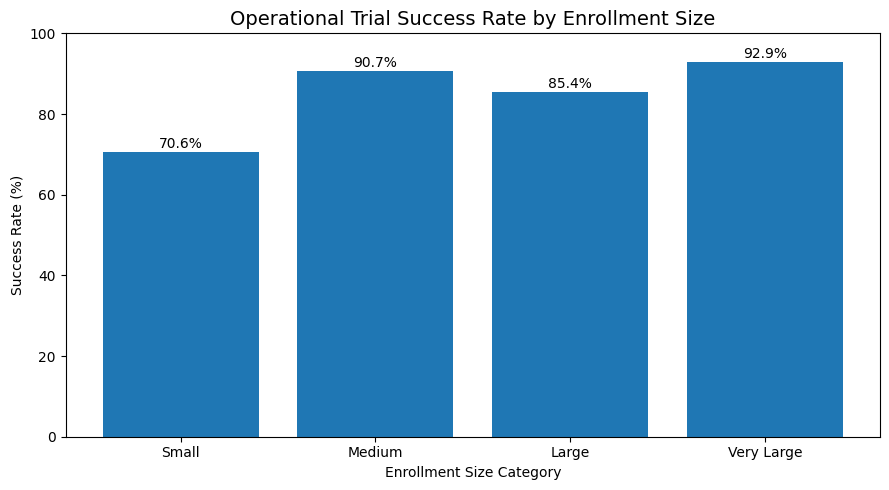

In [141]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,5))

bars = plt.bar(
    enrollment_success['enrollment_bucket'],
    enrollment_success['Success_Rate']
)

plt.title(
    'Operational Trial Success Rate by Enrollment Size',
    fontsize=14
)

plt.xlabel('Enrollment Size Category')
plt.ylabel('Success Rate (%)')

plt.ylim(0,100)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{height:.1f}%',
        ha='center'
    )

plt.tight_layout()
plt.show()

In [ ]:
# Figure Interpretation:
#
# Success rates generally increased with enrollment size.
# Small studies exhibited the lowest completion success rate
# (70.6%), whereas Medium, Large, and Very Large studies
# achieved success rates above 85%.
#
# This trend suggests that larger studies may possess greater
# operational stability and resources to successfully reach
# planned completion milestones.
#
# However, the Very Large category contained relatively few
# trials and should therefore be interpreted cautiously.

In [142]:
## FINAL SUMMARY TABLE
summary_table = pd.DataFrame({
    'Dimension': [
        'Indication × Phase',
        'Technology Type',
        'Target Class',
        'Enrollment Size'
    ],
    'Cohorts_Analyzed': [
        len(indication_phase_success),
        len(technology_success_rate),
        len(target_success_rate),
        len(enrollment_success)
    ]
})

summary_table

,Dimension,Cohorts_Analyzed
0,Indication × Phase,34
1,Technology Type,4
2,Target Class,19
3,Enrollment Size,4


In [ ]:
# Overall Cohort Analysis Summary
#
# Success rates were evaluated across four complementary dimensions:
# disease area and phase, therapeutic modality, biological target,
# and enrollment size. Together, these analyses provide a multi-level
# view of operational trial success patterns within the oncology
# clinical development landscape represented in the dataset.